In [1]:
import ROOT
import uproot
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.colors import Colormap,Normalize
from scipy.optimize import curve_fit
from scipy.special import erf, erfc
import glob
import os
import re

%jsroot on

ModuleNotFoundError: No module named 'ROOT'

In [13]:
def erfc_model(x, p0, p1, p2, p3):
    return (p0 / 2.0) * erfc((x - p1) / p2) + p3
def erf_model(x, p0, p1, p2, p3):
    return (p0 / 2.0) * erf((x - p1) / p2) + p3
def parabola(x, norm, x0, q):
    return norm*((x-x0)**2)+q
def abs_model(x, norm, x0, q):
    return norm*abs(x-x0)+q

def extract_focus(filepath: str, scan_coord: str = 'x', focal_coord: str = 'z', time_integ: float = 15., cmap_name: str = 'coolwarm'):
    cmap = plt.get_cmap(cmap_name)

    df = ROOT.RDataFrame('ch0', filepath)

    # 1. Define C++ calculation and extract ALL columns in a SINGLE event loop
    df_calculated = df.Define("integrated_area", f"ROOT::VecOps::Sum((volt - BlineMean) * ((time - tleft > 0) && (time - tleft < {time_integ:.1f})))")
    data = df_calculated.AsNumpy(columns=[focal_coord, scan_coord, "integrated_area"])

    z_all = data[focal_coord]
    x_all = data[scan_coord]
    area_all = data['integrated_area']

    # 2. Get unique coordinate steps
    unique_z = np.sort(np.unique(z_all))
    unique_x = np.sort(np.unique(x_all))
    dense_x = np.linspace(np.min(unique_x), np.max(unique_x), 200)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), width_ratios=[2, 1])
    norm = Normalize(vmin=np.min(unique_z), vmax=np.max(unique_z))

    # 3. Fast grouping in memory using pandas
    import pandas as pd

    df_pd = pd.DataFrame({focal_coord: z_all, scan_coord: x_all, 'area': area_all})
    grouped = df_pd.groupby([focal_coord, scan_coord])['area'].agg(['mean', 'std']).reset_index()

    spot_widths = []
    spot_err = []

    for z in unique_z:
        # print(f'Analyzing z = {z}')
        
        # Filter in-memory dataframe (microseconds speed)
        z_sub = grouped[grouped[focal_coord] == z].sort_values(scan_coord)
        
        x_vals = z_sub[scan_coord].values
        area_arr = z_sub['mean'].values
        area_std = z_sub['std'].values
        
        # Handle zero/NaN standard deviations for weighted fit
        area_std = np.where(area_std == 0, 1e-6, area_std)

        axes[0].errorbar(x_vals, area_arr, yerr=area_std, fmt='o', color=cmap(norm(z)), alpha=0.5, markersize=0.7)

        # Model fitting logic
        p0 = [np.max(area_arr), x_vals[len(x_vals)//2], 0.01, np.min(area_arr)]
        model = erf_model if area_arr[0] < area_arr[-1] else erfc_model
        
        popt, pcov = curve_fit(model, x_vals, area_arr, p0=p0, sigma=area_std)
        perr = np.sqrt(np.diag(pcov))
        axes[0].plot(dense_x, model(dense_x, *popt), color=cmap(norm(z)), linestyle='--', alpha=0.5)
        spot_widths.append(popt[2]*1000)
        spot_err.append(perr[2]*1000)
    spot_widths = np.asarray(spot_widths)
    spot_err = np.asarray(spot_err)
    min_arg = np.argmin(spot_widths)
    axes[1].errorbar(unique_z,spot_widths,yerr=spot_err,fmt='o',color='black')
    print("Minimum spot width = {:.2f} µm @ z = {} mm".format(spot_widths[min_arg],unique_z[min_arg]))
    try:
        params,pcov = curve_fit(abs_model,unique_z,spot_widths,p0=[1,unique_z[min_arg],spot_widths[min_arg]],sigma=spot_err)
        print(params)
        axes[1].plot(unique_z,abs_model(unique_z,*params),color='red')
        min_z = params[1]
        print("Fit results: minimum expected width = {:.2f} µm @ z = {:.2f} mm".format(abs_model(min_z,*params),min_z))
    except Exception as e:
        print(e)
    # Axes formatting
    path_chunks = filepath.strip().split('/')
    axes[0].set_title('Focal scan - {} ({})'.format(path_chunks[-2],"RED" if "red" in path_chunks[-1].lower() else "IR"))
    axes[0].set_xlabel(f"{scan_coord} [mm]")
    axes[0].set_ylabel("Area [nWb]")
    legend_elements = [
        Line2D([],[],color='black',marker='o',label='Data points'),
        Line2D([],[],color='black',linestyle='--',label='Fit line')
    ]
    axes[0].legend(handles=legend_elements)
    # Add colorbar for the first subplot
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, ax=axes[0], pad=0.001)
    cbar.set_label(f'{focal_coord} [mm]', fontsize=12)

    axes[1].set_xlabel(f"{focal_coord} [mm]")
    axes[1].set_ylabel("Spot width [µm]")
    fig.set_tight_layout(True)
    fig.set_dpi(200)

Analyzing file: /home/matteo/data/TCT-/nLGAD_W11_SP3_5-3/focus_scan_large_RED.root
Minimum spot width = 11.01 µm @ z = 38.5 mm
[19.85732652 38.62631012  7.58626986]
Fit results: minimum expected width = 7.59 µm @ z = 38.63 mm
Analyzing file: /home/matteo/data/TCT-/nLGAD_W11_SP3_5-3/focus_scan_fine_RED.root
Minimum spot width = 9.76 µm @ z = 38.575 mm
[12.86743222 38.58112467 10.58121042]
Fit results: minimum expected width = 10.58 µm @ z = 38.58 mm
Analyzing file: /home/matteo/data/TCT-/nLGAD_W11_SP3_5-3/focus_scan_IR.root
Minimum spot width = 16.97 µm @ z = 44.5 mm
[27.48536665 44.56488169 14.55297705]
Fit results: minimum expected width = 14.55 µm @ z = 44.56 mm


Error in <TClass::Load>: dictionary of class TMeasHeader not found
Error in <TClass::Load>: dictionary of class TMeasHeader not found


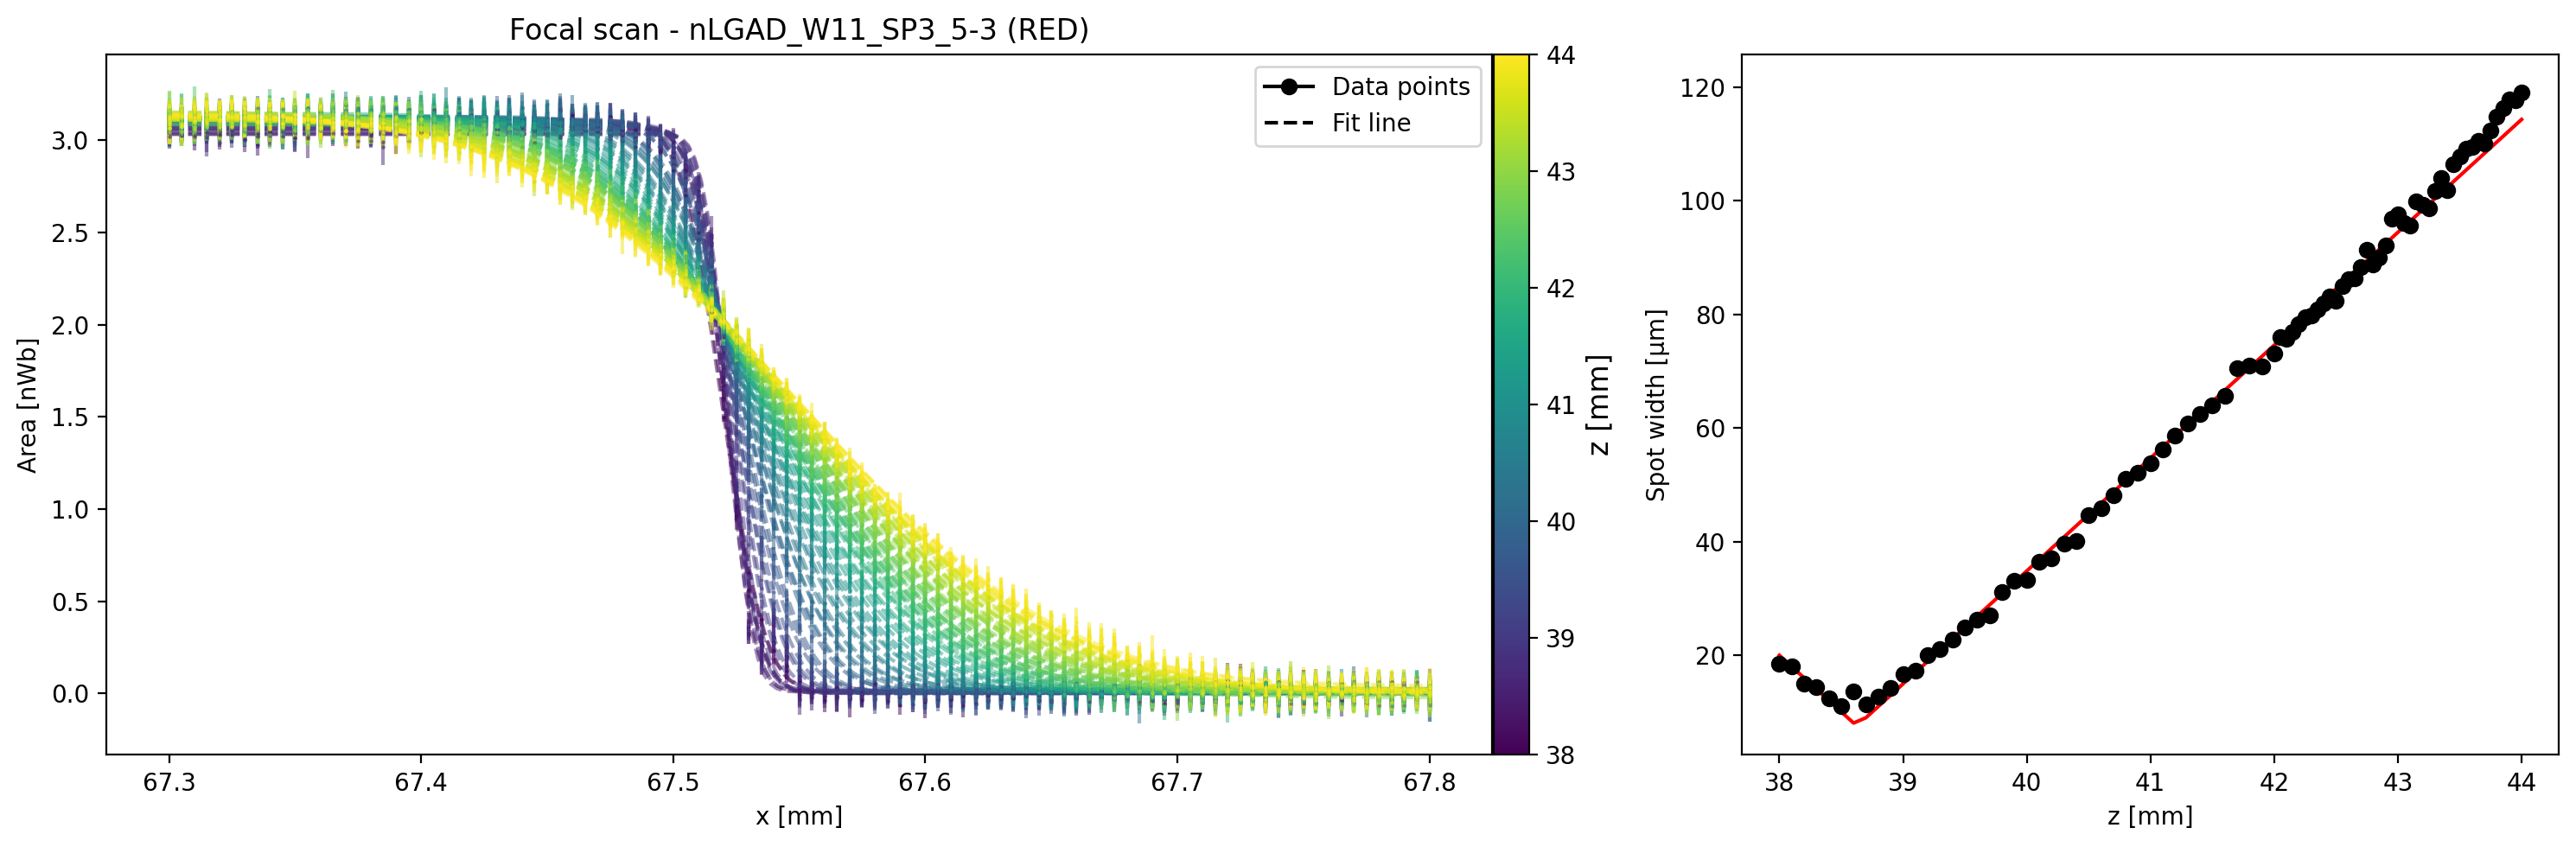

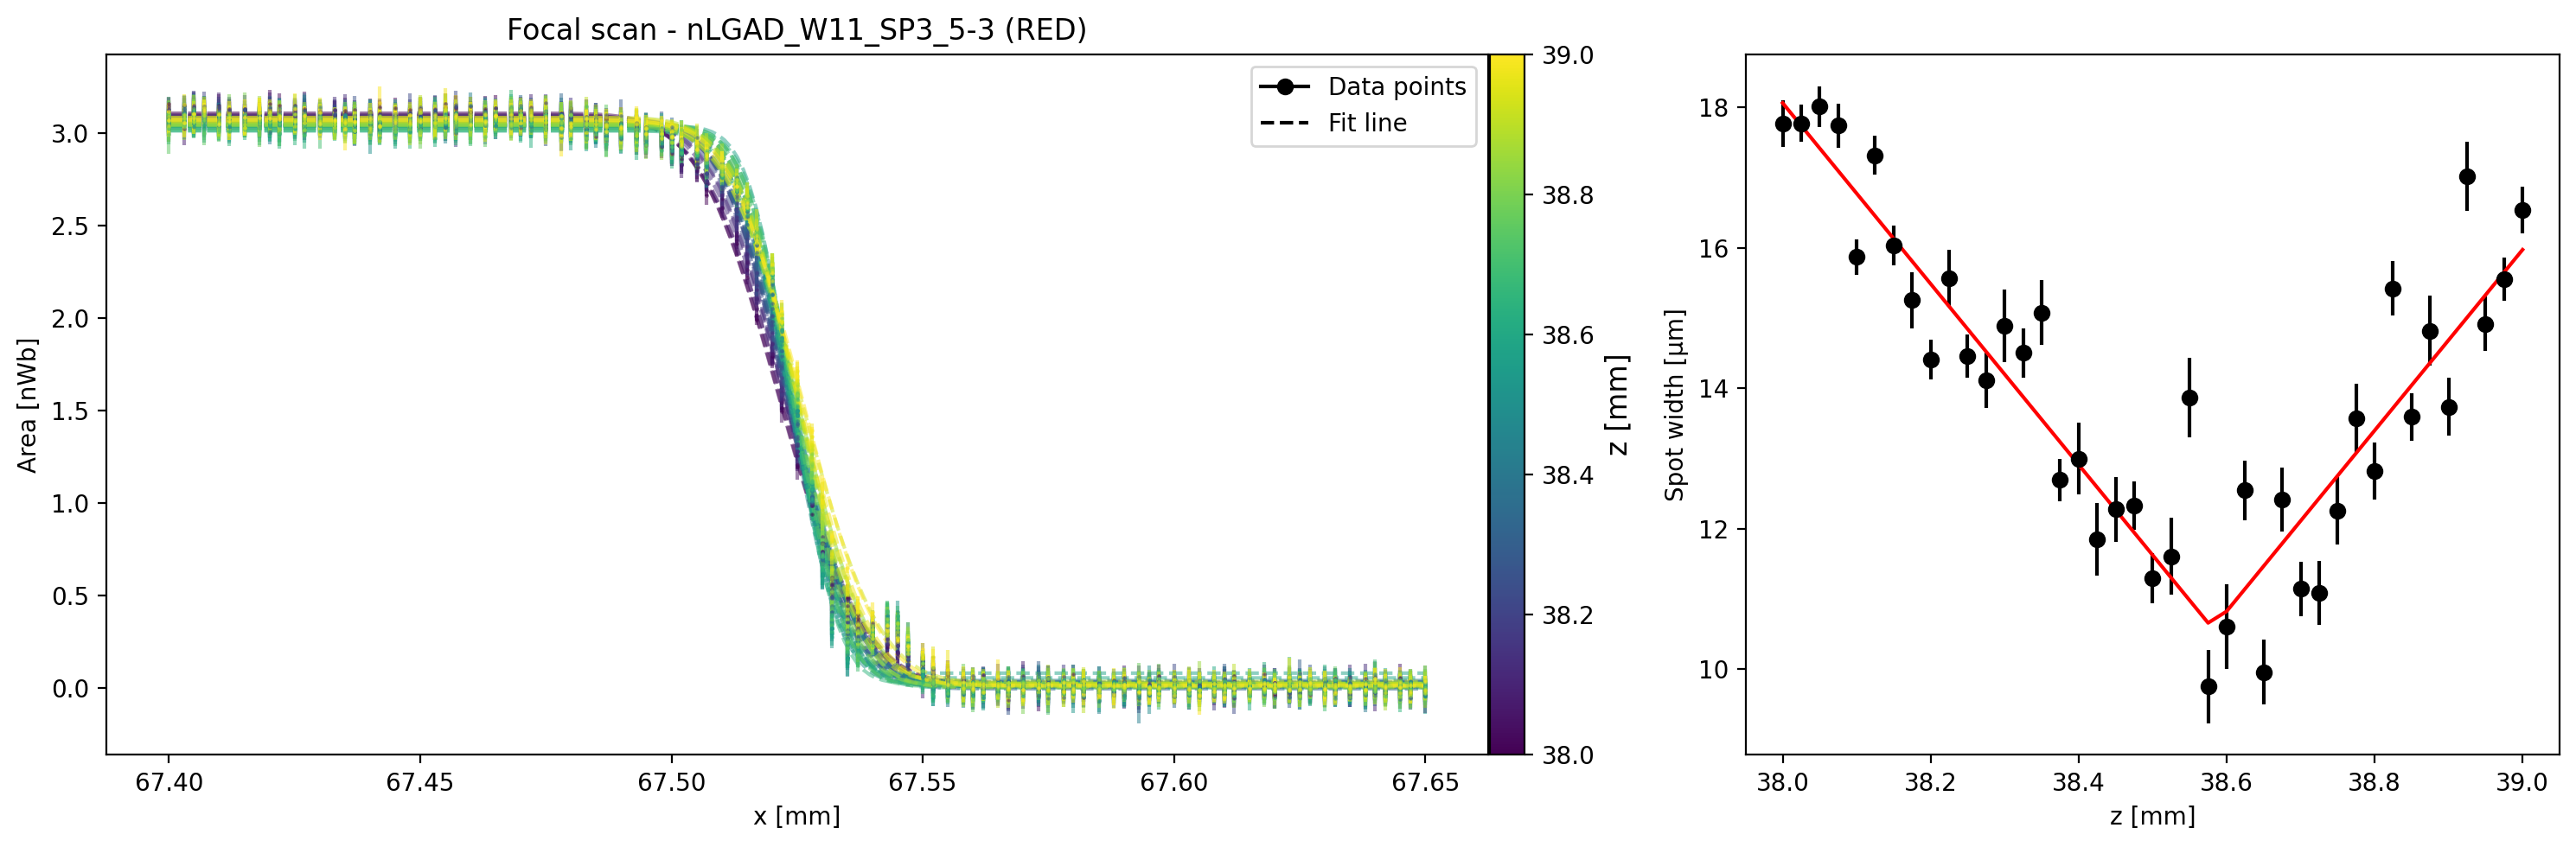

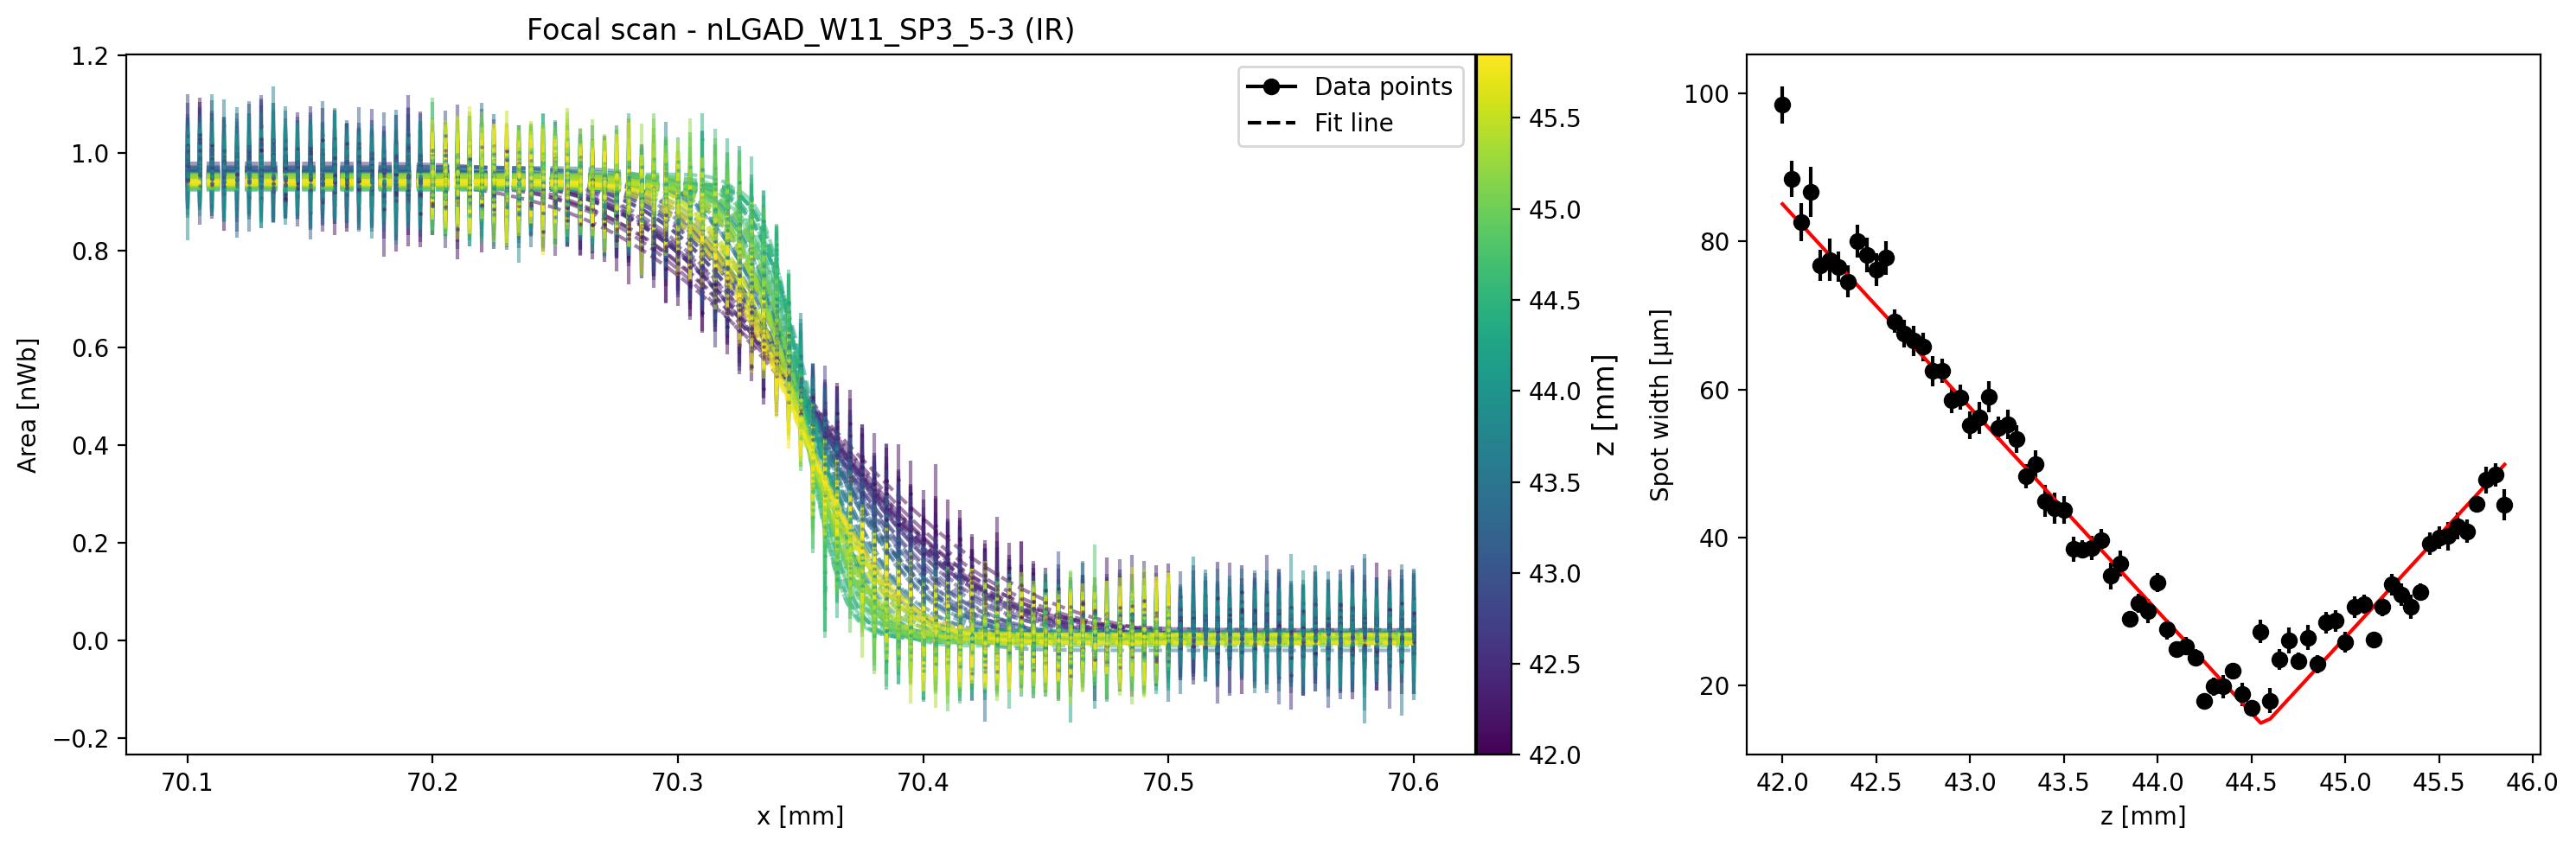

In [15]:
filepaths = [
    "/home/matteo/data/TCT-/nLGAD_W11_SP3_5-3/focus_scan_large_RED.root",
    "/home/matteo/data/TCT-/nLGAD_W11_SP3_5-3/focus_scan_fine_RED.root",
    "/home/matteo/data/TCT-/nLGAD_W11_SP3_5-3/focus_scan_IR.root"
]
time_integ = 15
scan_coord = 'x'
focal_coord = 'z'
cmap_name = 'viridis'

for filepath in filepaths:
    print("Analyzing file: {}".format(filepath))
    extract_focus(filepath,scan_coord,focal_coord,time_integ,cmap_name)